In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv
from pathlib import Path

In [6]:
load_dotenv()
SERVER = os.environ.get("DB_SERVER")
DATABASE = os.environ.get("DB_NAME")
DRIVER = os.environ.get("DB_DRIVER")
PATH_STRING = os.environ.get("FILE_PATH")

QUERIES_FOLDER = Path(PATH_STRING) / "queries" 
SQL_FILE_PATH = QUERIES_FOLDER / "cohort.sql"


In [ ]:
# extract the query into df

with open(SQL_FILE_PATH, 'r') as file: 
    sql_query = file.read()

engine = create_engine(f"mssql+pyodbc://{SERVER}/{DATABASE}?driver={DRIVER}&trusted_connection=yes")

df = pd.read_sql_query(sql_query, con=engine)


,order_id,customer_unique_id,order_purchase_timestamp,birth_date
0,e22acc9c116caa3f2b7121bbb380d08e,0000366f3b9a7992bf8c76cfdf3221e2,2018-05,2018-05
1,3594e05a005ac4d06a72673270ef9ec9,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05,2018-05
2,b33ec3b699337181488304f362a6b734,0000f46a3911fa3c0805444483337064,2017-03,2017-03
3,41272756ecddd9a9ed0180413cc22fb6,0000f6ccb0745a6a4b88665a16c9f078,2017-10,2017-10
4,d957021f1127559cd947b62533f484f7,0004aac84e0df4da2b147fca70cf8255,2017-11,2017-11
...,...,...,...,...
98202,725cf8e9c24e679a8a5a32cb92c9ce1e,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06,2017-06
98203,c71b9252fd7b3b263aaa4cb09319a323,fffea47cd6d3cc0a88bd621562a9d061,2017-12,2017-12
98204,fdc45e6c7555e6cb3cc0daca2557dbe1,ffff371b4d645b6ecea244b27531430a,2017-02,2017-02
98205,94d3ee0bc2a0af9d4fa47a4d63616e8d,ffff5962728ec6157033ef9805bacc48,2018-05,2018-05


<function matplotlib.pyplot.show(close=None, block=None)>

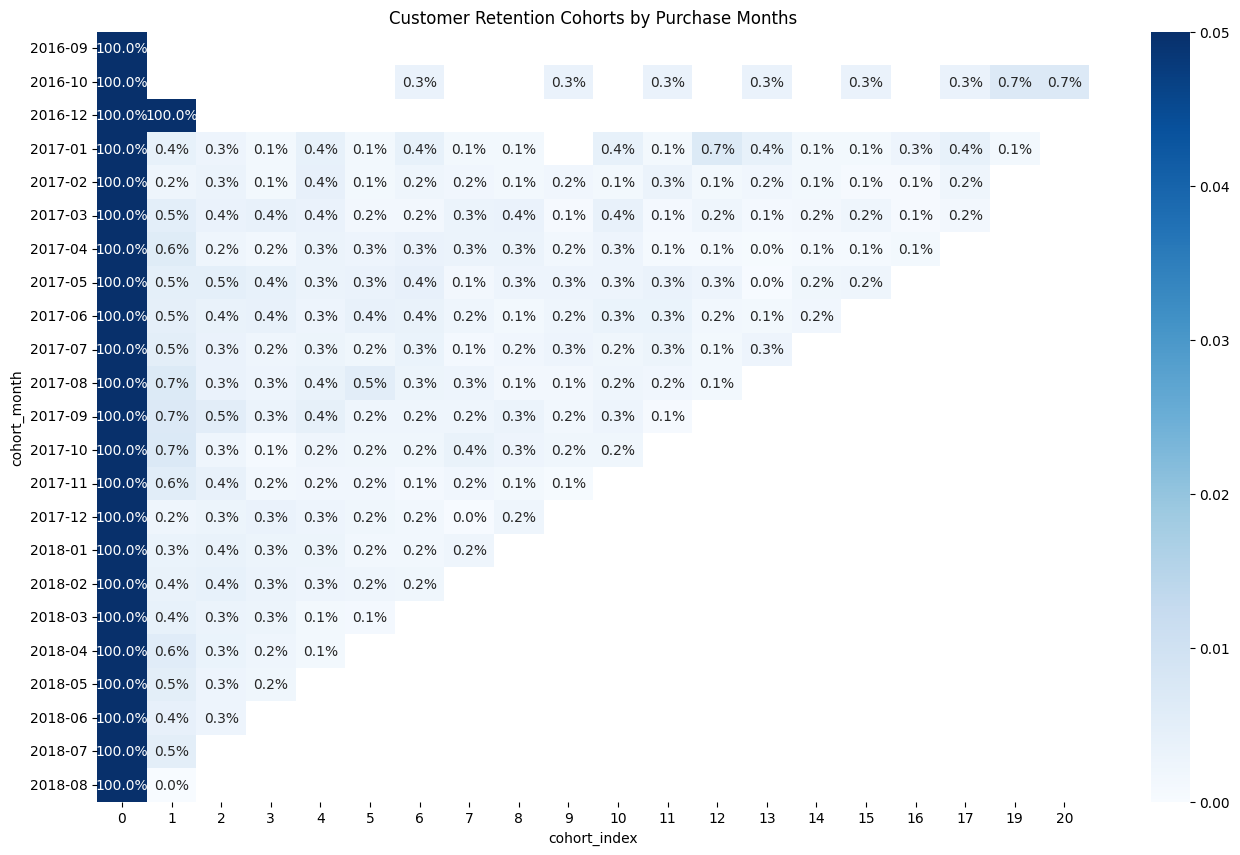

In [8]:
# convert dates to date time
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['birth_date'] = pd.to_datetime(df['birth_date'])

# get the months
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['cohort_month'] = df['birth_date'].dt.to_period('M')

# create cohort index
df['cohort_index'] = (df['purchase_month'] - df['cohort_month']).apply(lambda x: x.n if pd.notnull(x) else 0)

# prepare retention heat map data
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
retention_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')
cohort_sizes= retention_matrix.iloc[:,0]
retention_precentage = retention_matrix.divide(cohort_sizes, axis=0)

# make retention heat map
plt.figure(figsize=(16,10))
sns.heatmap(retention_precentage, annot=True, fmt='.1%', cmap='Blues', vmin=0.0, vmax=0.05)
plt.title('Customer Retention Cohorts by Purchase Months', fontsize=12)
plt.show

